In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Set the plot style for consistency
SAVE_PATH = "plots/"
os.makedirs(SAVE_PATH, exist_ok=True)

# Load FPS results for GPU (3080 Ti) and TPU from CSVs
df_gpu_320 = pd.read_csv("fps_3080ti_320_results.csv")
df_gpu_512 = pd.read_csv("fps_3080ti_512_results.csv")
df_tpu_320 = pd.read_csv("fps_tpu_320_results.csv")
df_tpu_320.yolo_model = df_tpu_320.yolo_model.str.replace("_full_integer_quant_edgetpu.tflite", '.pt')
df_tpu_320.yolo_model = df_tpu_320.yolo_model.str.replace("../tpu_weights/v8/320/", '')
df_tpu_512 = pd.read_csv("fps_tpu_512_results.csv")
df_tpu_512.yolo_model = df_tpu_512.yolo_model.str.replace("_full_integer_quant_edgetpu.tflite", '.pt')
df_tpu_512.yolo_model = df_tpu_512.yolo_model.str.replace("../tpu_weights/v8/512/", '')

# Add hardware and image size info
df_gpu_320["hardware"] = "GPU"; df_gpu_320["img_size"] = 320
df_gpu_512["hardware"] = "GPU"; df_gpu_512["img_size"] = 512
df_tpu_320["hardware"] = "TPU"; df_tpu_320["img_size"] = 320
df_tpu_512["hardware"] = "TPU"; df_tpu_512["img_size"] = 512

# Combine data frames for convenience when needed
df_all = pd.concat([df_gpu_320, df_gpu_512, df_tpu_320, df_tpu_512], ignore_index=True)

# Set plot style for clarity
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=1.1)
df_all.sample(5)

,tracker,yolo_model,reid_model,object_count,avg_fps,avg_time_per_frame,min_time_per_frame,max_time_per_frame,hardware,img_size
1822,bytetrack,yolov8n.pt,clip_market1501.pt,3,222.021812,4.506666,4.4,4.7,GPU,512
2805,ocsort,yolov8n.pt,clip_market1501.pt,1,35.579222,28.436363,21.6,48.7,TPU,320
639,bytetrack,yolov8x.pt,osnet_x0_75_market1501.pt,5,90.503976,11.055172,10.9,12.9,GPU,320
1139,imprassoc,yolov8n.pt,osnet_x0_5_market1501.pt,5,86.545255,11.846666,10.9,26.3,GPU,320
3630,imprassoc,yolov8s.pt,osnet_x0_5_market1501.pt,1,5.480100,187.196666,176.2,425.4,TPU,512


1. FPS Comparisons Across YOLO Models, ReID Models, Trackers, and Image Sizes

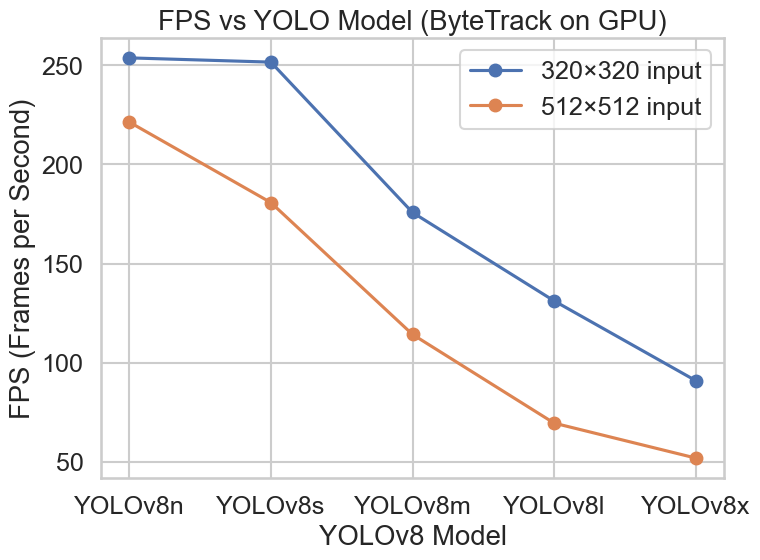

In [ ]:
# Impact of YOLO Model Size and Image Resolution on FPS (GPU)
# Filter for ByteTrack on GPU and 5 objects
df_byte_gpu = df_all[(df_all.tracker == "bytetrack") & (df_all.hardware == "GPU") & (df_all.object_count == 5)]

# Calculate average FPS for each YOLO model at 320 and 512
trackers = df_all.tracker.unique()
yolo_models = df_all.yolo_model.unique()
fps_320 = []
fps_512 = []
for model in yolo_models:
    fps_val_320 = df_byte_gpu[(df_byte_gpu.yolo_model == model) & (df_byte_gpu.img_size == 320)]["avg_fps"]
    fps_val_512 = df_byte_gpu[(df_byte_gpu.yolo_model == model) & (df_byte_gpu.img_size == 512)]["avg_fps"]
    # Use mean in case multiple runs; otherwise single value
    fps_320.append(fps_val_320.mean() if not fps_val_320.empty else None)
    fps_512.append(fps_val_512.mean() if not fps_val_512.empty else None)

# Plot FPS vs YOLO model for 320 and 512
plt.figure(figsize=(8,6))
yolo_labels = ["YOLOv8n", "YOLOv8s", "YOLOv8m", "YOLOv8l", "YOLOv8x"]
plt.plot(yolo_labels, fps_320, marker="o", label="320×320 input")
plt.plot(yolo_labels, fps_512, marker="o", label="512×512 input")
plt.title("FPS vs YOLO Model (ByteTrack on GPU)")
plt.ylabel("FPS (Frames per Second)")
plt.xlabel("YOLOv8 Model")
plt.legend()
plt.tight_layout()
plt.savefig(SAVE_PATH + "fps_yolo_models_gpu.png")
plt.show()


/var/folders/dj/d737lw992sd7ff5_jq6k5c240000gn/T/ipykernel_50122/3376342287.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["320p", "512p"], y=[fps_y8x_320, fps_y8x_512], palette="Paired")


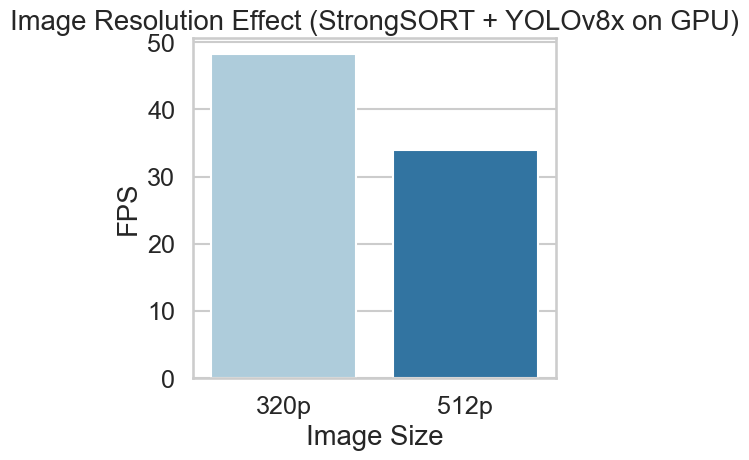

In [40]:
# Impact of Image Size on FPS (GPU)
# StrongSORT + YOLOv8x on GPU: compare 320 vs 512 image size FPS
fps_y8x_320 = df_gpu_320[(df_gpu_320.tracker=="strongsort") & (df_gpu_320.yolo_model=="yolov8x.pt") & 
                         (df_gpu_320.reid_model=="osnet_x1_0_market1501.pt")]["avg_fps"].mean()
fps_y8x_512 = df_gpu_512[(df_gpu_512.tracker=="strongsort") & (df_gpu_512.yolo_model=="yolov8x.pt") & 
                         (df_gpu_512.reid_model=="osnet_x1_0_market1501.pt")]["avg_fps"].mean()

plt.figure(figsize=(5,5))
sns.barplot(x=["320p", "512p"], y=[fps_y8x_320, fps_y8x_512], palette="Paired")
plt.title("Image Resolution Effect (StrongSORT + YOLOv8x on GPU)")
plt.ylabel("FPS")
plt.xlabel("Image Size")
plt.tight_layout()
plt.savefig(SAVE_PATH + "fps_resolution_effect.png")
plt.show()


2. GPU vs. TPU Performance Comparisons

/var/folders/dj/d737lw992sd7ff5_jq6k5c240000gn/T/ipykernel_50122/598653912.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="hardware", y="avg_fps", data=df_all, width=0.4, palette="Set2")


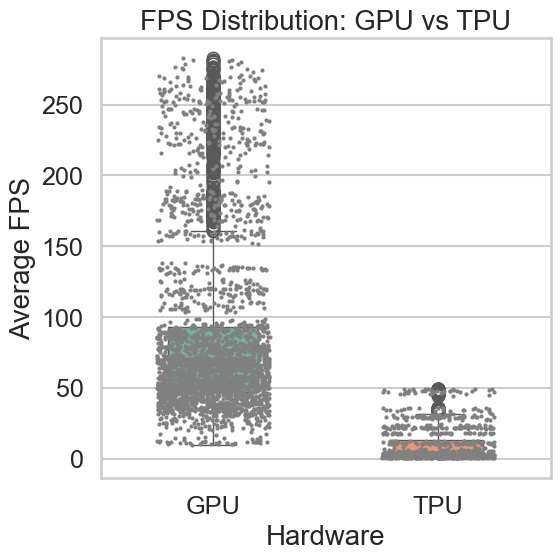

In [41]:
# Overall FPS distribution for GPU vs TPU
plt.figure(figsize=(6,6))
sns.boxplot(x="hardware", y="avg_fps", data=df_all, width=0.4, palette="Set2")
sns.stripplot(x="hardware", y="avg_fps", data=df_all, color="gray", size=3, jitter=0.25)  # individual points for detail
plt.title("FPS Distribution: GPU vs TPU")
plt.ylabel("Average FPS")
plt.xlabel("Hardware")
plt.yscale("linear")
plt.tight_layout()
plt.savefig(SAVE_PATH + "fps_distribution_gpu_vs_tpu.png")
plt.show()


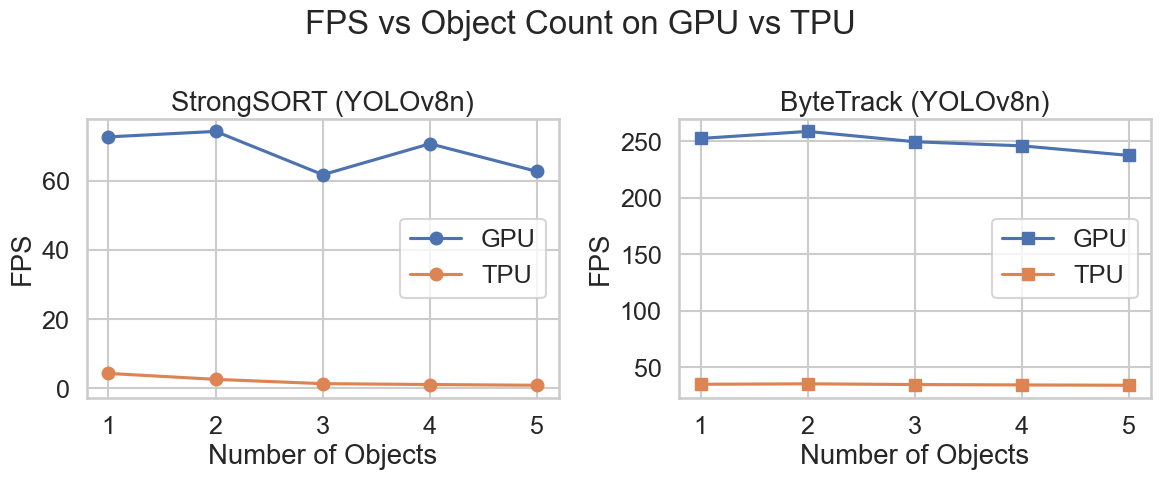

In [42]:
# Effect of Object Count on FPS: GPU vs TPU
# Prepare FPS data for StrongSORT and ByteTrack on GPU vs TPU as object count increases
obj_counts = sorted(df_all.object_count.unique())
strong_gpu = df_all[(df_all.tracker=="strongsort") & (df_all.hardware=="GPU") & (df_all.yolo_model=="yolov8n.pt") & 
                    (df_all.reid_model=="osnet_x1_0_market1501.pt")]
strong_tpu = df_all[(df_all.tracker=="strongsort") & (df_all.hardware=="TPU") & (df_all.yolo_model.str.contains("yolov8n")) & 
                    (df_all.reid_model=="osnet_x1_0_market1501.pt")]
byte_gpu   = df_all[(df_all.tracker=="bytetrack") & (df_all.hardware=="GPU") & (df_all.yolo_model=="yolov8n.pt")]
byte_tpu   = df_all[(df_all.tracker=="bytetrack") & (df_all.hardware=="TPU") & (df_all.yolo_model.str.contains("yolov8n"))]

avg_fps_strong_gpu = [strong_gpu[strong_gpu.object_count == n]["avg_fps"].mean() for n in obj_counts]
avg_fps_strong_tpu = [strong_tpu[strong_tpu.object_count == n]["avg_fps"].mean() for n in obj_counts]
avg_fps_byte_gpu   = [byte_gpu[byte_gpu.object_count == n]["avg_fps"].mean() for n in obj_counts]
avg_fps_byte_tpu   = [byte_tpu[byte_tpu.object_count == n]["avg_fps"].mean() for n in obj_counts]

# Plot side-by-side: StrongSORT vs ByteTrack scaling on each hardware
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=False)
axes[0].plot(obj_counts, avg_fps_strong_gpu, marker="o", label="GPU")
axes[0].plot(obj_counts, avg_fps_strong_tpu, marker="o", label="TPU")
axes[0].set_title("StrongSORT (YOLOv8n)")
axes[0].set_xlabel("Number of Objects")
axes[0].set_ylabel("FPS")
axes[0].legend()

axes[1].plot(obj_counts, avg_fps_byte_gpu, marker="s", label="GPU")
axes[1].plot(obj_counts, avg_fps_byte_tpu, marker="s", label="TPU")
axes[1].set_title("ByteTrack (YOLOv8n)")
axes[1].set_xlabel("Number of Objects")
axes[1].set_ylabel("FPS")
axes[1].legend()

plt.suptitle("FPS vs Object Count on GPU vs TPU")
plt.tight_layout()
plt.savefig(SAVE_PATH + "fps_object_count_gpu_vs_tpu.png")
plt.show()


3. Effect of Object Count on FPS for TPU (All Trackers)

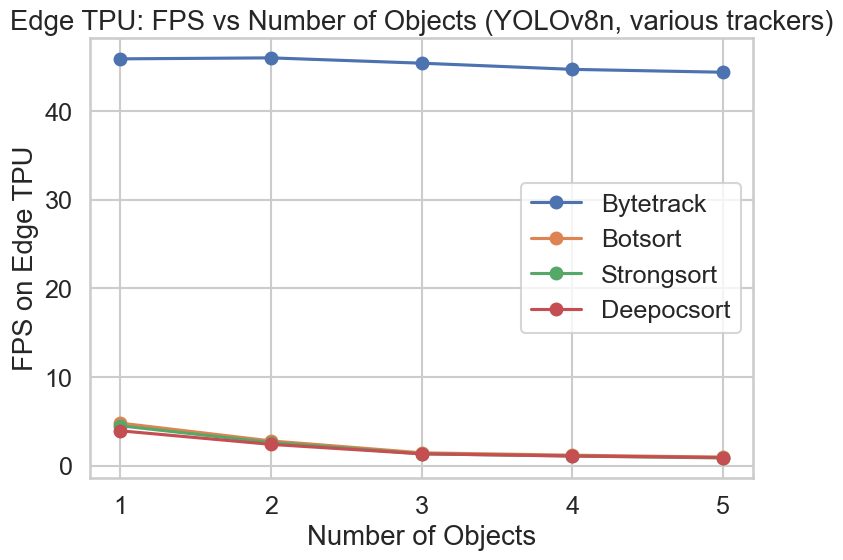

In [43]:
# FPS vs object count on TPU for multiple trackers (with YOLOv8n 320)
trackers = ["bytetrack", "botsort", "strongsort", "deepocsort"]
colors = {"bytetrack": "C0", "botsort": "C1", "strongsort": "C2", "deepocsort": "C3"}

plt.figure(figsize=(8,6))
for tr in trackers:
    df_tr = df_tpu_320[(df_tpu_320.tracker == tr) & (df_tpu_320.yolo_model.str.contains("yolov8n")) & 
                       (df_tpu_320.reid_model == "osnet_x1_0_market1501.pt")]
    avg_fps = df_tr.groupby("object_count")["avg_fps"].mean()
    if avg_fps.empty:
        continue
    plt.plot(avg_fps.index, avg_fps.values, marker="o", label=tr.capitalize(), color=colors[tr])

plt.title("Edge TPU: FPS vs Number of Objects (YOLOv8n, various trackers)")
plt.xlabel("Number of Objects")
plt.ylabel("FPS on Edge TPU")
plt.legend()
plt.tight_layout()
plt.savefig(SAVE_PATH + "tpu_fps_vs_objects_trackers.png")
plt.show()


4. Interval Plots for FPS Distributions (Average – Min – Max)

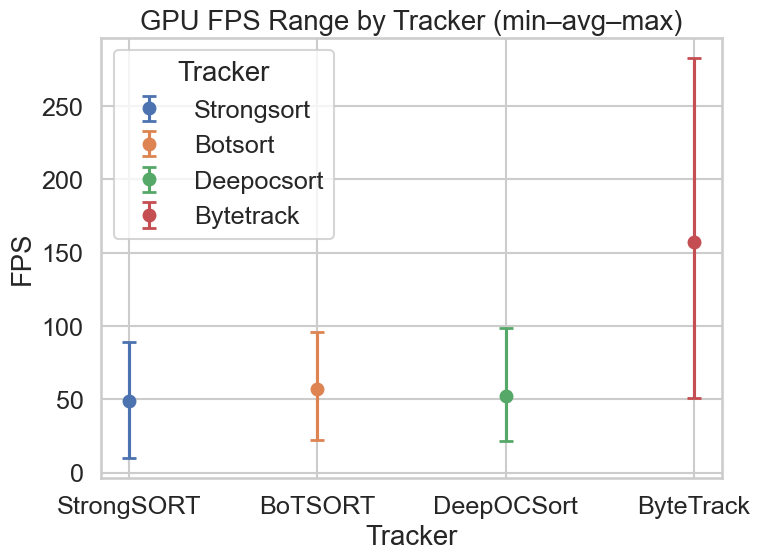

In [ ]:
# FPS Range by Tracker on GPU
# Calculate avg, min, max FPS for each tracker on GPU (all image sizes and YOLO models)
trackers = ["strongsort", "botsort", "deepocsort", "bytetrack"]
stats_gpu = {tr: (pd.concat([df_gpu_320, df_gpu_512], ignore_index=True)
                  .loc[df_all.tracker==tr, "avg_fps"]
                  .agg(["mean","min","max"]).values) for tr in trackers}

# Plot interval (min-max) for each tracker on GPU
plt.figure(figsize=(8,6))
for i, tr in enumerate(trackers):
    mean, min_val, max_val = stats_gpu[tr]
    plt.errorbar(i, mean, yerr=[[mean - min_val], [max_val - mean]], 
                 fmt='o', capsize=5, capthick=2, label=tr.capitalize())
plt.xticks(range(len(trackers)), ["StrongSORT","BoTSORT","DeepOCSort","ByteTrack"])
plt.title("GPU FPS Range by Tracker (min–avg–max)")
plt.ylabel("FPS")
plt.xlabel("Tracker")
plt.legend(title="Tracker")
plt.tight_layout()
plt.savefig(SAVE_PATH + "fps_interval_trackers_gpu.png")
plt.show()


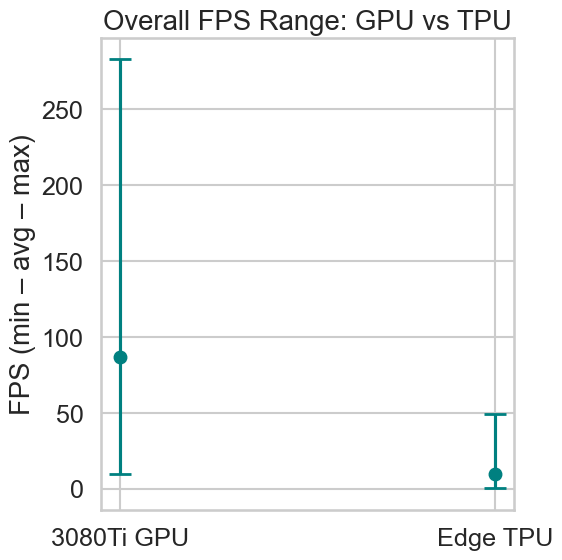

In [47]:
# Overall FPS Range: GPU vs TPU
# Compute overall average, min, max FPS on GPU and TPU
gpu_fps = df_all[df_all.hardware=="GPU"]["avg_fps"]
tpu_fps = df_all[df_all.hardware=="TPU"]["avg_fps"]
avg_gpu, min_gpu, max_gpu = gpu_fps.mean(), gpu_fps.min(), gpu_fps.max()
avg_tpu, min_tpu, max_tpu = tpu_fps.mean(), tpu_fps.min(), tpu_fps.max()

plt.figure(figsize=(6,6))
hardware = ["3080Ti GPU", "Edge TPU"]
avg_vals = [avg_gpu, avg_tpu]
y_err_lower = [avg_gpu - min_gpu, avg_tpu - min_tpu]
y_err_upper = [max_gpu - avg_gpu, max_tpu - avg_tpu]
plt.errorbar(hardware, avg_vals, yerr=[y_err_lower, y_err_upper], fmt='o', capsize=8, capthick=2, color='teal')
plt.title("Overall FPS Range: GPU vs TPU")
plt.ylabel("FPS (min – avg – max)")
plt.tight_layout()
plt.savefig(SAVE_PATH + "fps_interval_gpu_vs_tpu.png")
plt.show()


5. Performance Metrics (MOTA, HOTA, IDF1) Comparisons Between Configurations

/var/folders/dj/d737lw992sd7ff5_jq6k5c240000gn/T/ipykernel_50122/2846343152.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Tracker", y=metric, data=metrics_sel, order=tracker_order, ax=ax, palette="deep")
/var/folders/dj/d737lw992sd7ff5_jq6k5c240000gn/T/ipykernel_50122/2846343152.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["StrongSORT","BoTSORT","DeepOCSort","ByteTrack"], rotation=15)
/var/folders/dj/d737lw992sd7ff5_jq6k5c240000gn/T/ipykernel_50122/2846343152.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Tracker", y=metric, data=metrics_sel, order=tracker_orde

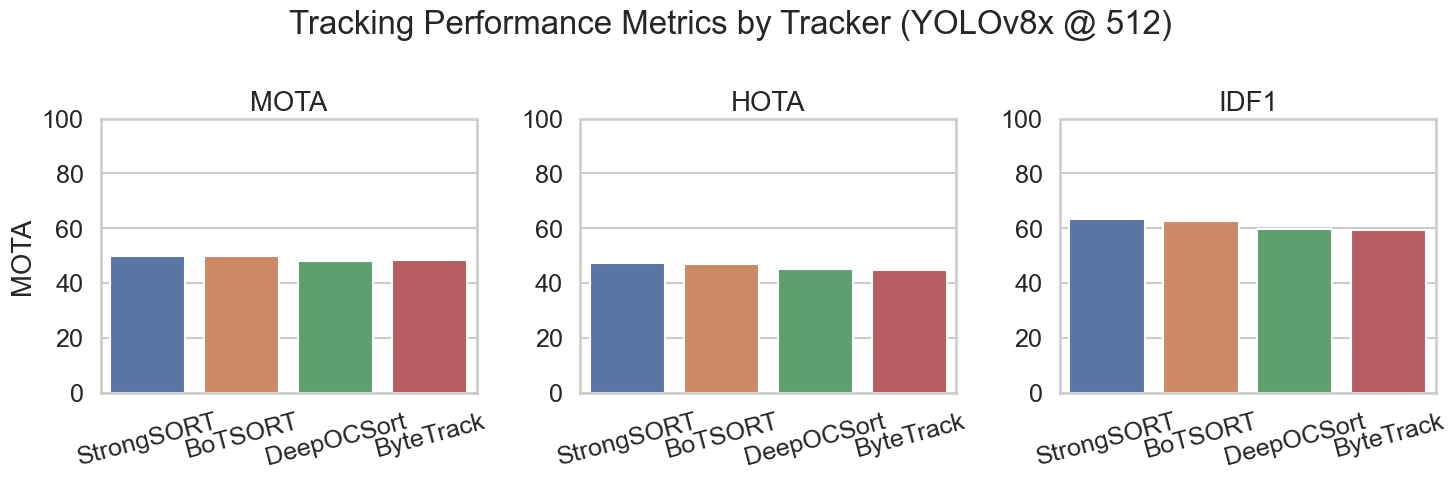

In [49]:
# Load the sorted results with tracking metrics
metrics_df = pd.read_csv("./results_20250221_205048/sorted_results.csv")

# Filter for a consistent setting: use YOLOv8x 512 results and a common ReID (osnet_x1_0) for trackers
metrics_sel = metrics_df[(metrics_df["ImgSz"] == 512) & 
                         (metrics_df["YOLO Model"].str.contains("yolov8x")) & 
                         (metrics_df["REID Model"] == "osnet_x1_0_market1501.pt")]
# Take the first entry for each tracker (metrics are constant across reID variants for ByteTrack, etc.)
metrics_sel = metrics_sel.groupby("Tracker").first().reset_index()

# Prepare data for plotting
tracker_order = ["strongsort", "botsort", "deepocsort", "bytetrack"]
metrics_sel = metrics_sel[metrics_sel.Tracker.isin(tracker_order)]
metrics_sel.Tracker = pd.Categorical(metrics_sel.Tracker, categories=tracker_order, ordered=True)
metrics_sel = metrics_sel.sort_values("Tracker")

# Plot MOTA, HOTA, IDF1 for each tracker
fig, axes = plt.subplots(1, 3, figsize=(15,5))
metrics_list = ["MOTA", "HOTA", "IDF1"]
for ax, metric in zip(axes, metrics_list):
    sns.barplot(x="Tracker", y=metric, data=metrics_sel, order=tracker_order, ax=ax, palette="deep")
    ax.set_title(metric)
    ax.set_ylim(0, 100)
    ax.set_xlabel("")
    if metric == "MOTA":
        ax.set_ylabel(metric)
    else:
        ax.set_ylabel("")
    # Capitalize tracker labels for display
    ax.set_xticklabels(["StrongSORT","BoTSORT","DeepOCSort","ByteTrack"], rotation=15)
plt.suptitle("Tracking Performance Metrics by Tracker (YOLOv8x @ 512)")
plt.tight_layout()
plt.savefig(SAVE_PATH + "tracker_metrics_comparison.png")
plt.show()
